In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
df1 = pd.read_csv("../../data/csv/air_pollution.csv")

In [55]:
df1.head()

,Unnamed: 0,ParentLocationCode,SpatialDim,Dim1,Value,NumericValue,Date,IndicatorCode
0,0,EMR,ARE,SEX_BTSX,7 [5-9],7.26606,2022-08-26T09:40:54+02:00,AIR_10
1,1,AFR,ZMB,SEX_FMLE,266 [78-492],266.23209,2022-08-26T09:41:03+02:00,AIR_10
2,2,WPR,AUS,SEX_BTSX,1 [0-1],0.72083,2022-08-26T09:40:54+02:00,AIR_10
3,3,AFR,COG,SEX_FMLE,249 [43-528],249.31205,2022-08-26T09:40:55+02:00,AIR_10
4,4,AMR,ATG,SEX_FMLE,5 [1-11],4.77712,2022-08-26T09:40:54+02:00,AIR_10


In [56]:
df1.tail()

,Unnamed: 0,ParentLocationCode,SpatialDim,Dim1,Value,NumericValue,Date,IndicatorCode
491071,491071,AMR,VEN,RESIDENCEAREATYPE_CITY,17.66 [13.32-23.12],17.66130,2022-08-12T09:00:45+02:00,SDGPM25
491072,491072,WPR,FJI,RESIDENCEAREATYPE_TOWN,8.05 [4.89-12.98],8.05264,2022-08-12T08:59:27+02:00,SDGPM25
491073,491073,AFR,AGO,RESIDENCEAREATYPE_TOWN,24.33 [5.75-71.32],24.33109,2022-08-12T08:58:50+02:00,SDGPM25
491074,491074,EMR,KWT,RESIDENCEAREATYPE_URB,68.79 [59.52-79.71],68.78559,2022-08-12T08:59:49+02:00,SDGPM25
491075,491075,EUR,AUT,RESIDENCEAREATYPE_RUR,11.03 [10.66-11.43],11.02630,2022-08-12T08:58:56+02:00,SDGPM25


In [57]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491076 entries, 0 to 491075
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          491076 non-null  int64  
 1   ParentLocationCode  437864 non-null  object 
 2   SpatialDim          491076 non-null  object 
 3   Dim1                490882 non-null  object 
 4   Value               491076 non-null  object 
 5   NumericValue        490896 non-null  float64
 6   Date                491076 non-null  object 
 7   IndicatorCode       491076 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 30.0+ MB


In [58]:
'''
 0   ParentLocationCode  :object  :Mã khu vực
 1   SpatialDim          :object  :Không gian địa lý (mã quốc gia hoặc vùng)
 2   Dim1                :object  :Chiều để phân loại phụ 
 3   Value               :object  :Giá trị gốc của WHO (để kiểm tra dữ liệu thô)
 4   NumericValue        :float64 :Phiên bản số hóa của Value (tính toán, thống kê, vẽ)
 5   Date                :object  :Năm hoặc khoảng thời gian
 6   IndicatorCode       :object  :Mã chỉ số y tế
'''

'\n 0   ParentLocationCode  :object  :Mã khu vực\n 1   SpatialDim          :object  :Không gian địa lý (mã quốc gia hoặc vùng)\n 2   Dim1                :object  :Chiều để phân loại phụ \n 3   Value               :object  :Giá trị gốc của WHO (để kiểm tra dữ liệu thô)\n 4   NumericValue        :float64 :Phiên bản số hóa của Value (tính toán, thống kê, vẽ)\n 5   Date                :object  :Năm hoặc khoảng thời gian\n 6   IndicatorCode       :object  :Mã chỉ số y tế\n'

In [59]:
df1.describe()

,Unnamed: 0,NumericValue
count,491076.000000,4.908960e+05
mean,245537.500000,1.146485e+05
std,141761.574734,1.871427e+06
min,0.000000,0.000000e+00
25%,122768.750000,7.391068e+00
50%,245537.500000,9.427950e+01
75%,368306.250000,1.735496e+03
max,491075.000000,2.110137e+08


In [60]:
df1.describe(include='object')

,ParentLocationCode,SpatialDim,Dim1,Value,Date,IndicatorCode
count,437864,491076,490882,491076,491076,491076
unique,6,240,8,277375,2099,33
top,EUR,WPR,SEX_FMLE,0 [0-0],2024-10-03T16:19:34.33+02:00,AIR_15
freq,119377,3554,165212,45469,71060,35530


In [61]:
df1.isnull()

,Unnamed: 0,ParentLocationCode,SpatialDim,Dim1,Value,NumericValue,Date,IndicatorCode
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
491071,False,False,False,False,False,False,False,False
491072,False,False,False,False,False,False,False,False
491073,False,False,False,False,False,False,False,False
491074,False,False,False,False,False,False,False,False


In [62]:
df1["ParentLocationCode"].isnull().value_counts()
# ParentLocationCode
# False    437864
# True      53212
# Name: count, dtype: int64
#--Tui định bỏ hết, tại đống này cỡ 10% mà mình có tận 500k, xử lí hơi khó

ParentLocationCode
False    437864
True      53212
Name: count, dtype: int64

In [63]:
df1.dropna(subset = ["ParentLocationCode"],axis = 0, inplace = True )
df1["ParentLocationCode"].isnull().value_counts()


ParentLocationCode
False    437864
Name: count, dtype: int64

In [64]:
df1["SpatialDim"].isnull().value_counts()


SpatialDim
False    437864
Name: count, dtype: int64

In [65]:
df1["Dim1"].isnull().value_counts()
# Dim1
# False    490882
# True        194
# Name: count, dtype: int64
#-- này chắc bỏ luôn quá :)))

Dim1
False    437670
True        194
Name: count, dtype: int64

In [66]:
df1.dropna(subset = ["Dim1"], axis = 0, inplace=True)
df1["Dim1"].isnull().value_counts()


Dim1
False    437670
Name: count, dtype: int64

In [67]:
df1["Value"].isnull().value_counts()
#Cột này trong lúc xử lí thì bỏ cột do nó được chuyển sang cột NumericValue rồi

Value
False    437670
Name: count, dtype: int64

In [68]:
df1.drop(columns= ["Value"], axis=1 , errors= "ignore", inplace=True)
df1.columns

Index(['Unnamed: 0', 'ParentLocationCode', 'SpatialDim', 'Dim1',
       'NumericValue', 'Date', 'IndicatorCode'],
      dtype='object')

In [69]:
df1["NumericValue"].isnull().value_counts()
# NumericValue
# False    490896
# True        180
# Name: count, dtype: int64
#này tui định xử lí bằng mean()

NumericValue
False    437490
True        180
Name: count, dtype: int64

In [70]:
df1["Date"].isnull().value_counts()
#-- tui định đổi định dạng trc, còn ngày tháng thì chắc chia them dummy + bins

Date
False    437670
Name: count, dtype: int64

In [71]:
df1["Date"] = pd.to_datetime(df1["Date"], format="ISO8601")

In [72]:
df1.head()

,Unnamed: 0,ParentLocationCode,SpatialDim,Dim1,NumericValue,Date,IndicatorCode
0,0,EMR,ARE,SEX_BTSX,7.26606,2022-08-26 09:40:54+02:00,AIR_10
1,1,AFR,ZMB,SEX_FMLE,266.23209,2022-08-26 09:41:03+02:00,AIR_10
2,2,WPR,AUS,SEX_BTSX,0.72083,2022-08-26 09:40:54+02:00,AIR_10
3,3,AFR,COG,SEX_FMLE,249.31205,2022-08-26 09:40:55+02:00,AIR_10
4,4,AMR,ATG,SEX_FMLE,4.77712,2022-08-26 09:40:54+02:00,AIR_10


In [73]:
df1["IndicatorCode"].isnull().value_counts()
#-- file này ít indicator code thì group theo được , mấy file kia nhiều code thì làm sao

IndicatorCode
False    437670
Name: count, dtype: int64

In [74]:
df1["IndicatorCode"].unique()

array(['AIR_10', 'AIR_11', 'AIR_12', 'AIR_15', 'AIR_16', 'AIR_17',
       'AIR_35', 'AIR_39', 'AIR_4', 'AIR_41', 'AIR_42', 'AIR_43',
       'AIR_45', 'AIR_46', 'AIR_5', 'AIR_51', 'AIR_52', 'AIR_6', 'AIR_60',
       'AIR_62', 'AIR_7', 'AIR_71', 'AIR_72', 'AIR_73', 'AIR_74',
       'AIR_75', 'AIR_8', 'AIR_9', 'AIR_90', 'SDGAIRBOD', 'SDGAIRBODA',
       'SDGPM25'], dtype=object)

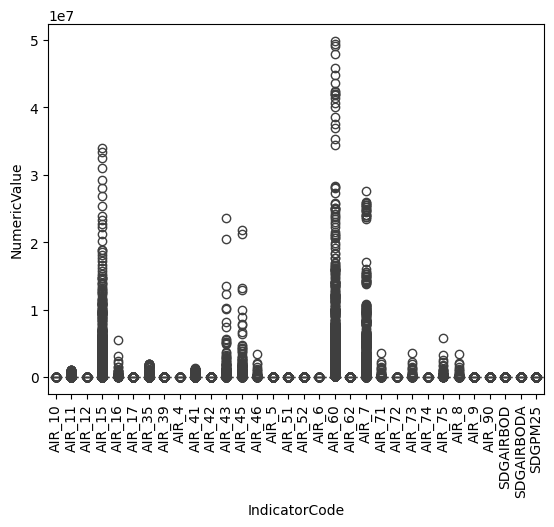

In [75]:
sns.boxplot(df1, x = "IndicatorCode", y = "NumericValue")
plt.xticks(rotation=90);

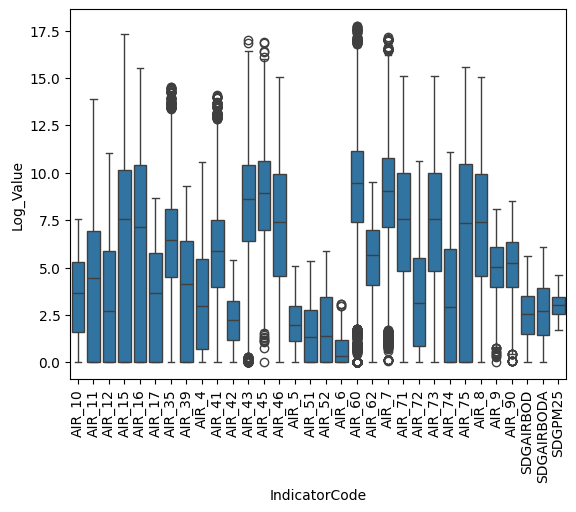

In [76]:
df1['Log_Value'] = np.log1p(df1['NumericValue'])
sns.boxplot(data=df1, x="IndicatorCode", y="Log_Value")
plt.xticks(rotation=90);

In [77]:
# AIR_10	Số ca tử vong do ô nhiễm không khí trong nhà (HAP) - Bệnh phổi tắc nghẽn mãn tính (COPD).
# AIR_11	@Số ca tử vong do HAP - Ung thư phổi.
# AIR_12	Số ca tử vong do HAP - Bệnh tim thiếu máu cục bộ (IHD).
# AIR_15	@Số ca tử vong do ô nhiễm không khí ngoài trời (AAP) - Tổng hợp các bệnh.
# AIR_16	@Tỷ lệ tử vong do ô nhiễm không khí (trên 100.000 dân) - Hiệu ứng kết hợp của HAP và AAP.
# AIR_17	Tổng số ca tử vong do hiệu ứng kết hợp của ô nhiễm không khí trong nhà và ngoài trời.
# --------------------------------------------------------------------------------------------------
# AIR_35	@DALYs do ô nhiễm không khí ngoài trời (AAP).(Số năm sống được điều chỉnh theo mức độ bệnh tật (DALY))
# AIR_39	DALYs do ô nhiễm không khí trong nhà (HAP).
# AIR_41	@DALYs do HAP - Nhiễm trùng đường hô hấp dưới cấp tính (ALRI) ở trẻ em.
# AIR_42	DALYs do HAP - Ung thư phổi.
# AIR_43	@DALYs do HAP - Bệnh tim thiếu máu cục bộ (IHD).
# AIR_45	@DALYs do HAP - Đột quỵ (Stroke).
# AIR_46	@DALYs do HAP - Bệnh phổi tắc nghẽn mãn tính (COPD).
# --------------------------------------------------------------------------------------------------
# AIR_60	@Tỷ lệ dân số chủ yếu sử dụng nhiên liệu và công nghệ sạch để nấu ăn.
# AIR_62	Tỷ lệ dân số chủ yếu sử dụng nhiên liệu và công nghệ sạch để sưởi ấm.
# AIR_71	@Tỷ lệ dân số sử dụng nhiên liệu sạch để thắp sáng.
# AIR_72	Số lượng người (tính bằng triệu) không có quyền truy cập vào nhiên liệu nấu ăn sạch.
# AIR_73	@Tỷ lệ dân số sử dụng nhiên liệu rắn (củi, than, phân động vật...) để nấu ăn.
# AIR_74	Tỷ lệ dân số sử dụng dầu hỏa (kerosene) để nấu ăn.
# AIR_75	@Tỷ lệ dân số sử dụng khí hóa lỏng (LPG) để nấu ăn.
# --------------------------------------------------------------------------------------------------
# AIR_4	    Nồng độ trung bình năm của bụi mịn (PM2.5) tại các khu vực đô thị.
# AIR_5	    Nồng độ PM2.5 trung bình năm (trọng số theo dân số) - Tổng thể quốc gia.
# AIR_6	    Nồng độ PM2.5 trung bình năm tại các khu vực nông thôn.
# AIR_7	    @Tỷ lệ dân số tiếp xúc với nồng độ PM2.5 vượt quá hướng dẫn của WHO.
# AIR_8	    @Phân bổ dân số theo các mức độ nồng độ PM2.5 khác nhau.
# AIR_9	    Nồng độ PM2.5 tại các thành phố lớn (thành phố có dữ liệu đo đạc).
# SDGPM25	Chỉ số SDG 11.6.2: Nồng độ trung bình năm của bụi mịn (PM2.5) trong không khí tại các thành phố.
# --------------------------------------------------------------------------------------------------
# SDGAIRBOD: (SDG Indicator 3.9.1) Tỷ lệ tử vong do ô nhiễm không khí trong nhà và ngoài trời (thường tính trên 100.000 dân).

# SDGAIRBODA: Biến thể của SDGAIRBOD, thường dùng để chỉ số lượng ca tử vong tuyệt đối hoặc dữ liệu đã được chuẩn hóa theo độ tuổi.

# AIR_51 & AIR_52: Thường liên quan đến các kịch bản dự báo hoặc dữ liệu điều chỉnh về gánh nặng bệnh tật do môi trường.

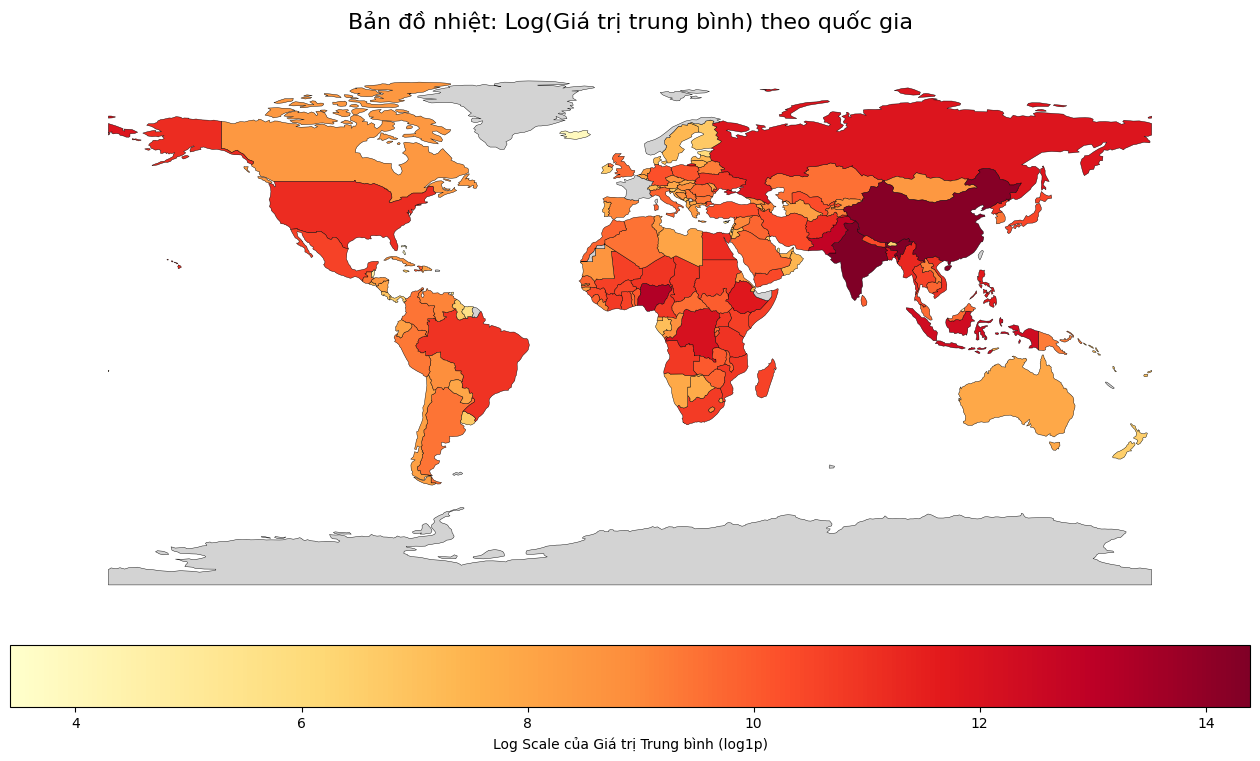

In [78]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np  # Thêm thư viện numpy để tính log

# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Giữ nguyên)
# ==============================
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")
df1["Date"] = pd.to_datetime(df1["Date"], errors="coerce")

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df1_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df1_grouped["LogMeanValue"] = np.log1p(df1_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df1_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Giá trị trung bình) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()

In [79]:
# AIR_4	    Nồng độ trung bình năm của bụi mịn (PM2.5) tại các khu vực đô thị.
# AIR_5	    Nồng độ PM2.5 trung bình năm (trọng số theo dân số) - Tổng thể quốc gia.
# AIR_6	    Nồng độ PM2.5 trung bình năm tại các khu vực nông thôn.
# AIR_7	    @Tỷ lệ dân số tiếp xúc với nồng độ PM2.5 vượt quá hướng dẫn của WHO.
# AIR_8	    @Phân bổ dân số theo các mức độ nồng độ PM2.5 khác nhau.
# AIR_9	    Nồng độ PM2.5 tại các thành phố lớn (thành phố có dữ liệu đo đạc).
# SDGPM25	Chỉ số SDG 11.6.2: Nồng độ trung bình năm của bụi mịn (PM2.5) trong không khí tại các thành phố.
list_IndicatorCode = ["AIR_4","AIR_5","AIR_6","AIR_7","AIR_8","AIR_9","SDGPM25"]